# College Events Data Analyzer & Predictor Dashboard
A Python console project that predicts event participants and classifies feedback sentiment using basic ML and manual text processing.

#  📄 Project Bio
"College Events Data Analyzer & Feedback Sentiment Predictor" is a Python-based console project that analyzes college event data to predict participant count and classify student feedback sentiment. It uses basic Python, manual text processing, and Logistic Regression models.

# ✅ What I Used in the Project
1. pandas – for data loading and handling

2. sklearn.linear_model.LogisticRegression – for training ML models

3. sklearn.preprocessing.LabelEncoder – to convert text labels to numbers

4. Basic Python functions – for text cleaning (lowercase, remove punctuation)

5. Console-based app – built using simple input() and print() functions

6. Two ML models:
    Sentiment prediction (Positive / Neutral / Negative)

7. Participant prediction (based on budget, department, event type)

# Loading Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df=pd.read_csv("/content/drive/MyDrive/My Project/college_events_dataset.csv")


display(df.head())



,Event_ID,Event_Name,Department,Event_Type,Date,Participants,Budget,Feedback
0,101,CodeSprint,CSE,Technical,2024-11-10,120,5000,Great learning experience!
1,102,ArtAttack,Arts,Cultural,2024-12-01,80,3000,Fun and colorful event.
2,103,VolleyFest,Sports,Sports,2025-01-15,200,7000,Exciting matches and crowd.
3,104,Robowars,ECE,Technical,2024-10-05,95,6000,Amazing robotics skills showcased.
4,105,DJ Night,Management,Cultural,2024-12-20,180,8000,Loud but enjoyable.


# Data Visualization

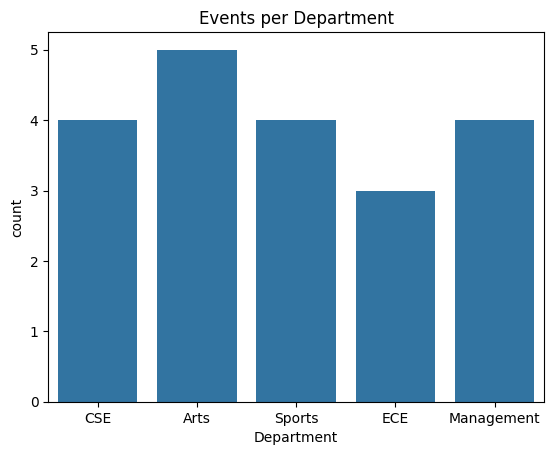

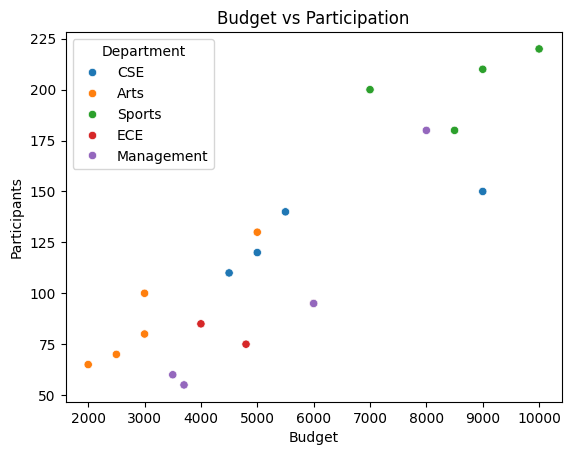

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.countplot(data=df, x='Department')
plt.title("Events per Department")
plt.show()


sns.scatterplot(data=df, x='Budget', y='Participants', hue='Department')
plt.title("Budget vs Participation")
plt.show()


In [ ]:

labels = [
    1, 1, 1, 1, 0,
    1, 1, 1, 1, -1,
    1, 1, 0, 1, 1,
    1, 1, 1, 1, 0
]

df['Sentiment_Label'] = labels


# Clean the Feedback Text

In [ ]:
def clean_text(text):
    return ''.join(c for c in text.lower() if c.isalnum() or c == ' ')

df['Clean_Feedback'] = df['Feedback'].apply(clean_text)


In [ ]:
# Build vocabulary manually
vocab = set()
for text in df['Clean_Feedback']:
    words = text.split()
    vocab.update(words)

# Index each word
vocab = sorted(vocab)
word_index = {word: i for i, word in enumerate(vocab)}

# Convert text to bag of words
def text_to_bow(text):
    vec = [0] * len(vocab)
    for word in text.split():
        if word in word_index:
            vec[word_index[word]] += 1
    return vec

X_text = [text_to_bow(text) for text in df['Clean_Feedback']]
y_sent = df['Sentiment_Label']


In [ ]:
from sklearn.linear_model import LogisticRegression

sentiment_model = LogisticRegression()
sentiment_model.fit(X_text, y_sent)


LogisticRegression()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
le_dept = LabelEncoder()
le_type = LabelEncoder()

df['Dept_Code'] = le_dept.fit_transform(df['Department'])
df['Type_Code'] = le_type.fit_transform(df['Event_Type'])

# Training data for participants prediction
X_part = df[['Budget', 'Dept_Code', 'Type_Code']]
y_part = df['Participants']

# Train model
participation_model = LogisticRegression()
participation_model.fit(X_part, y_part)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
def main():
    while True:
        print("\n--- College Event Analyzer ---")
        print("1. View event data")
        print("2. Predict sentiment from feedback")
        print("3. Predict participants for a new event")
        print("4. Exit")

        choice = input("Enter your choice (1-4): ")

        if choice == '1':
            display(df[['Event_Name', 'Department', 'Event_Type', 'Participants', 'Feedback']])

        elif choice == '2':
            feedback = input("Enter feedback: ")
            cleaned = clean_text(feedback)
            vec = [text_to_bow(cleaned)]
            pred = sentiment_model.predict(vec)[0]
            label = "Positive" if pred == 1 else "Neutral" if pred == 0 else "Negative"
            print(f"Predicted Sentiment: {label}")

        elif choice == '3':
            try:
                budget = float(input("Enter budget: "))
                dept = input(f"Enter department {list(le_dept.classes_)}: ")
                etype = input(f"Enter event type {list(le_type.classes_)}: ")

                dept_code = le_dept.transform([dept])[0]
                type_code = le_type.transform([etype])[0]

                pred = participation_model.predict([[budget, dept_code, type_code]])[0]
                print(f"Estimated participants: {int(pred)}")
            except Exception as e:
                print("Error in input. Please try again.")

        elif choice == '4':
            print("Exiting. Thank you!")
            break

        else:
            print("Invalid choice. Please select 1-4.")

if __name__ == "__main__":
    main()


--- College Event Analyzer ---
1. View event data
2. Predict sentiment from feedback
3. Predict participants for a new event
4. Exit
Enter your choice (1-4): 3
Enter budget: 3000
Enter department ['Arts', 'CSE', 'ECE', 'Management', 'Sports']: CSE
Enter event type ['Cultural', 'Sports', 'Technical']: Technical


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Estimated participants: 110

--- College Event Analyzer ---
1. View event data
2. Predict sentiment from feedback
3. Predict participants for a new event
4. Exit
Enter your choice (1-4): 4
Exiting. Thank you!
